# Имитационная модель аэропорта: регистрация пассажиров

Строю модель процесса регистрации пассажиров в аэропорту с помощью библиотеки `simpy`, а затем по результатам моделирования провожу статистический анализ.

По сути это система массового обслуживания (очередь), состоящая из трёх частей:

- **Входящий поток пассажиров.** Люди приходят по одному в случайные моменты времени, в среднем раз в 2 минуты. Интервалы между приходами берутся из экспоненциального распределения — такой поток называется пуассоновским и хорошо описывает случайный приход клиентов.
- **Стойки регистрации.** Их несколько (у меня 3). Это значит, что одновременно обслуживаются не более 3 человек, а остальные ждут в общей очереди по принципу «первым пришёл — первым обслужен» (FIFO).
- **Время обслуживания.** У каждого пассажира оно случайное, но колеблется около среднего значения (5 минут) с небольшим разбросом. Беру его из нормального распределения, которое хорошо подходит для длительности стандартной операции.

В теории массового обслуживания такая система обозначается как **M/G/N**: случайный (пуассоновский) поток заявок, произвольное (нормальное) время обслуживания и N каналов обслуживания.

## 1. Импорт библиотек и параметры модели

Подключаю необходимые библиотеки и выношу все настройки модели наверх в отдельные константы. Это удобно для экспериментов: чтобы изменить, например, число стоек, достаточно поправить одно значение, не затрагивая логику модели.

Параметры подобраны так, чтобы система была достаточно загружена, но оставалась устойчивой. Коэффициент загрузки получается около 0.83 — он меньше 1, поэтому очередь не растёт бесконечно, но при этом загрузка высокая, и ожидание в очереди реально возникает (иначе измерять было бы нечего).

In [1]:
import simpy 
import random 
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats 

N_DESKS = 3
ARRIVAL_RATE = 0.5
SERVICE_MEAN = 5.0
SERVICE_STD = 1.0
SIM_TIME = 480
N_RUNS = 30

rho = ARRIVAL_RATE * SERVICE_MEAN / N_DESKS
print(f'Коэффициент загрузки = {rho:.3f} (меньше 1? {rho < 1})')

Коэффициент загрузки = 0.833 (меньше 1? True)


## 2. Класс Airport — стойки регистрации

Здесь описываю стойки регистрации. В `simpy` для этого есть готовый объект `Resource`: ему задаётся ёмкость (capacity), а дальше он сам ведёт очередь и не допускает к обслуживанию больше заявок, чем есть стоек. Это избавляет от необходимости вручную программировать логику очереди.

Метод `serve` описывает само обслуживание: пассажир занимает стойку на некоторое время, которое берётся случайным из нормального распределения. Нюанс: нормальное распределение иногда может выдать отрицательное значение, а время не может быть отрицательным, поэтому через `max` ограничиваю его снизу значением 0.1.

In [2]:
class Airport:
    """Стойки регистрации и процесс обслуживания одного пассажира."""

    def __init__(self, env, n_desks, service_mean, service_std, rng):
        self.env = env
        self.desks = simpy.Resource(env, capacity=n_desks)
        self.service_mean = service_mean    # среднее время обслуживания
        self.service_std = service_std      # стандартное отклонение
        self.rng = rng                      # генератор случайных чисел прогона

    def serve(self, passenger_id):
        """Обслуживание одного пассажира на стойке."""
        service_time = max(0.1, self.rng.normalvariate(self.service_mean, self.service_std))
        yield self.env.timeout(service_time)
        return service_time

## 3. Процесс пассажира и генератор потока

Функция `passenger` описывает поведение одного пассажира от прихода до ухода из системы:

1. Приходит и запрашивает стойку. Если есть свободная — занимает её, если нет — встаёт в очередь и ждёт.
2. Как только получает стойку, фиксируется время ожидания в очереди — это основная величина, которую я измеряю.
3. Проходит обслуживание.
4. Покидает систему, стойка освобождается автоматически за счёт конструкции `with`.

Функция `passenger_source` — это генератор входящего потока. Она в бесконечном цикле выдерживает случайную паузу и запускает нового пассажира. Именно случайные паузы между приходами и обеспечивают пуассоновский поток.

In [3]:
def passenger(env, name, airport, stats):
    """Один пассажир: приход -> очередь -> обслуживание -> уход."""
    arrival_time = env.now

    with airport.desks.request() as request:
        yield request 
    
        wait_time = env.now - arrival_time
        stats['wait_times'].append(wait_time)

        service_time = yield env.process(airport.serve(name))
        stats['service_times'].append(service_time)


def passenger_source(env, airport, arrival_rate, stats):
    """Генератор входящего потока: создаёт пассажиров со случайными интервалами."""
    passenger_id = 0
    while True:
        interarrival = airport.rng.expovariate(arrival_rate)
        yield env.timeout(interarrival)
        passenger_id += 1
        
        env.process(passenger(env, passenger_id, airport, stats))

## 4. Один прогон модели

Запуск модели оформляю в виде функции `run_simulation(seed)`. Параметр `seed` задаёт начальное состояние генератора случайных чисел: при одинаковом seed результат прогона полностью воспроизводится, а при разных seed получаются независимые прогоны.

Функция возвращает статистику прогона, из которой мне нужно среднее время ожидания. Сразу делаю один тестовый прогон, чтобы убедиться, что модель работает корректно и значения адекватные. По одному прогону делать выводы нельзя — это только проверка.

In [4]:
def run_simulation(seed):
    """Один прогон модели; возвращает статистику (списки времён)."""
    rng = random.Random(seed)
    env = simpy.Environment()

    stats = {'wait_times': [], 'service_times': []}

    airport = Airport(env, N_DESKS, SERVICE_MEAN, SERVICE_STD, rng)
    env.process(passenger_source(env, airport, ARRIVAL_RATE, stats))

    env.run(until=SIM_TIME)

    return stats


test_stats = run_simulation(seed=42)
print(f'Обслужено за смену: {len(test_stats["service_times"])} чел.')
print(f'Среднее время ожидания в очереди: {np.mean(test_stats["wait_times"]):.2f} мин')
print(f'Среднее время обслуживания: {np.mean(test_stats["service_times"]):.2f} мин')

Обслужено за смену: 214 чел.
Среднее время ожидания в очереди: 1.71 мин
Среднее время обслуживания: 4.98 мин


## 5. Серия из 30 прогонов

Результат одного прогона случаен, поэтому опираться на него нельзя. Применяю метод независимых прогонов: запускаю модель 30 раз, каждый раз с новым seed, и из каждого прогона беру одно итоговое число — среднее время ожидания.

Число 30 выбрано не случайно: при 30 и более прогонах распределение среднего хорошо приближается нормальным, что позволяет корректно построить доверительный интервал. При меньшем числе оценка будет ненадёжной.

В качестве seed использую номера прогонов: 1, 2, 3, … 30. Главное, чтобы они были разными — это обеспечивает независимость прогонов.

In [5]:
mean_wait_times = []

for run in range(1, N_RUNS + 1):
    run_stats = run_simulation(seed=run)             # прогон
    avg_wait = np.mean(run_stats['wait_times'])      # среднее ожидание в этом прогоне
    mean_wait_times.append(avg_wait)                 # сохраняем результат
    print(f'Прогон {run:2d} (seed={run:2d}): среднее ожидание = {avg_wait:.3f} мин')

mean_wait_times = np.array(mean_wait_times)

Прогон  1 (seed= 1): среднее ожидание = 3.203 мин
Прогон  2 (seed= 2): среднее ожидание = 1.675 мин
Прогон  3 (seed= 3): среднее ожидание = 7.913 мин
Прогон  4 (seed= 4): среднее ожидание = 2.808 мин
Прогон  5 (seed= 5): среднее ожидание = 2.033 мин
Прогон  6 (seed= 6): среднее ожидание = 3.812 мин
Прогон  7 (seed= 7): среднее ожидание = 3.269 мин
Прогон  8 (seed= 8): среднее ожидание = 2.038 мин
Прогон  9 (seed= 9): среднее ожидание = 3.667 мин
Прогон 10 (seed=10): среднее ожидание = 3.158 мин
Прогон 11 (seed=11): среднее ожидание = 2.666 мин
Прогон 12 (seed=12): среднее ожидание = 1.952 мин
Прогон 13 (seed=13): среднее ожидание = 3.871 мин
Прогон 14 (seed=14): среднее ожидание = 1.460 мин
Прогон 15 (seed=15): среднее ожидание = 0.670 мин
Прогон 16 (seed=16): среднее ожидание = 2.237 мин
Прогон 17 (seed=17): среднее ожидание = 4.119 мин
Прогон 18 (seed=18): среднее ожидание = 1.810 мин
Прогон 19 (seed=19): среднее ожидание = 3.375 мин
Прогон 20 (seed=20): среднее ожидание = 5.149 мин


## 6. Гистограмма распределения

Строю гистограмму 30 полученных значений, чтобы наглядно увидеть разброс результатов между прогонами. Красной линией отмечаю общее среднее. Ожидаю, что значения сгруппируются вокруг центра.

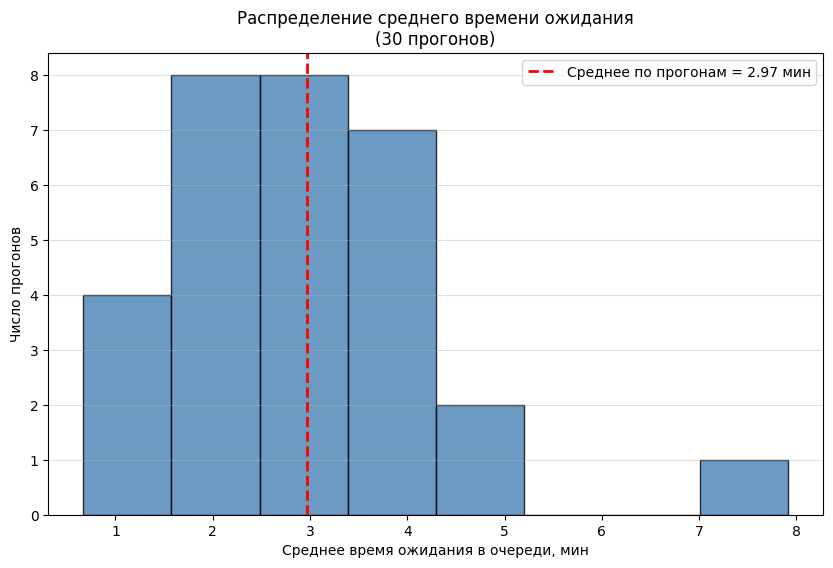

In [6]:
plt.figure(figsize=(10, 6))

plt.hist(mean_wait_times, bins=8, color='steelblue',
         edgecolor='black', alpha=0.8)

overall_mean = np.mean(mean_wait_times)
plt.axvline(overall_mean, color='red', linestyle='--', linewidth=2,
            label=f'Среднее по прогонам = {overall_mean:.2f} мин')

plt.title('Распределение среднего времени ожидания\n'
          f'({N_RUNS} прогонов)')
plt.xlabel('Среднее время ожидания в очереди, мин')
plt.ylabel('Число прогонов')
plt.legend()
plt.grid(axis='y', alpha=0.4)
plt.show()

## 7. Доверительный интервал

Завершающий шаг. Есть 30 значений, и нужно дать не просто среднее, а диапазон, в котором лежит истинное среднее время ожидания. Это и есть доверительный интервал.

Считаю среднее по 30 прогонам и стандартное отклонение, затем делю отклонение на корень из числа прогонов — получаю стандартную ошибку среднего. Умножаю её на коэффициент t из распределения Стьюдента (для 95% уровня доверия и 30 прогонов он примерно равен 2.045) и получаю границы интервала.

Итог трактуется так: с вероятностью 95% истинное среднее время ожидания находится между нижней и верхней границей интервала. Это и есть корректный итоговый результат эксперимента.

In [7]:
n = len(mean_wait_times)

mean_estimate = np.mean(mean_wait_times)       # среднее по прогонам
std_estimate = np.std(mean_wait_times, ddof=1) # стандартное отклонение (ddof=1 - для выборки)
sem = std_estimate / np.sqrt(n)                # стандартная ошибка среднего

# коэффициент t (95% доверие, n-1 степеней свободы)
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)

# границы доверительного интервала
margin = t_crit * sem
ci_lower = mean_estimate - margin
ci_upper = mean_estimate + margin

print('================ ИТОГИ ЭКСПЕРИМЕНТА ================')
print(f'Число прогонов: {n}')
print(f'Среднее время ожидания: {mean_estimate:.3f} мин')
print(f'Стандартное отклонение: {std_estimate:.3f} мин')
print(f'Стандартная ошибка среднего: {sem:.3f} мин')
print(f'Коэффициент t({n-1}; 0.975): {t_crit:.3f}')
print(f'95% доверительный интервал: [{ci_lower:.3f}; {ci_upper:.3f}] мин')
print(f'Итого: {mean_estimate:.2f} ± {margin:.2f} мин')

================ ИТОГИ ЭКСПЕРИМЕНТА ================
Число прогонов: 30
Среднее время ожидания: 2.966 мин
Стандартное отклонение: 1.415 мин
Стандартная ошибка среднего: 0.258 мин
Коэффициент t(29; 0.975): 2.045
95% доверительный интервал: [2.438; 3.494] мин
Итого: 2.97 ± 0.53 мин
